In [ ]:
# --- repo bootstrap -------------------------------------------------------------
# All paths in this notebook are relative to the repository root, so switch there
# first (the notebook can then be launched from any directory) and put src/ on the
# import path for `epochalypse_fitting`, `epochalypse_figures`, `run_*_periodograms`.
import os, sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src" / "epochalypse_fitting.py").exists())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
print("repo root:", ROOT)


In [14]:
import matplotlib 
import matplotlib.pyplot as plt
matplotlib.rc('xtick', labelsize=18) 
matplotlib.rc('ytick', labelsize=18) 
matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
matplotlib.rc('text', usetex=True)


In [15]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d


def add_mass_radius_from_pecaut(
    sample_sources_df,
    pecaut_path="./data/pecaut_mamajek.txt",
    parallax_col="parallax",
    gmag_col="phot_g_mean_mag_dr3",
    source_id_col="gaia_source_id",
):
    """
    Add absolute Gaia G magnitude, interpolated mass, and interpolated radius
    using the Pecaut & Mamajek table.

    Outputs:
        abs_G          : absolute Gaia G magnitude
        mass_interp    : mass in solar masses
        radius_interp  : radius in solar radii

    Uses fill_value=np.nan, so stars outside the table's M_G range
    are not extrapolated.
    """

    colnames = [
        "SpT", "Teff", "logT", "BCv", "logL", "Mbol", "R_Rsun", "Mv",
        "B-V", "Bt-Vt", "G-V", "Bp-Rp", "G-Rp", "M_G", "b-y", "U-B",
        "V-Rc", "V-Ic", "V-Ks", "J-H", "H-Ks", "M_J", "M_Ks", "Ks-W1",
        "W1-W2", "W1-W3", "W1-W4", "g-r", "i-z", "z-Y", "Msun", "SpT2"
    ]

    pecaut = pd.read_csv(
        pecaut_path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=colnames,
    )

    # Convert needed columns to numeric
    for col in ["M_G", "Msun", "R_Rsun"]:
        pecaut[col] = pd.to_numeric(pecaut[col], errors="coerce")

    # Keep only usable rows
    pecaut = pecaut.dropna(subset=["M_G", "Msun", "R_Rsun"])

    # Sort by absolute Gaia G magnitude
    pecaut = pecaut.sort_values("M_G")

    # Interpolation functions, no extrapolation
    mass_from_absG = interp1d(
        pecaut["M_G"],
        pecaut["Msun"],
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    radius_from_absG = interp1d(
        pecaut["M_G"],
        pecaut["R_Rsun"],
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    # Work on a copy so the original dataframe is not modified unexpectedly
    df = sample_sources_df.copy()

    # Ensure numeric input columns
    df[gmag_col] = pd.to_numeric(df[gmag_col], errors="coerce")
    df[parallax_col] = pd.to_numeric(df[parallax_col], errors="coerce")

    valid = (
        df[gmag_col].notna()
        & df[parallax_col].notna()
        & (df[parallax_col] > 0)
    )

    # Initialize outputs
    df["abs_G"] = np.nan
    df["mass_interp"] = np.nan
    df["radius_interp"] = np.nan

    # Absolute G magnitude
    df.loc[valid, "abs_G"] = (
        df.loc[valid, gmag_col]
        + 5 * np.log10(df.loc[valid, parallax_col] / 1000)
        + 5
    )

    # Interpolate mass and radius
    df.loc[valid, "mass_interp"] = mass_from_absG(df.loc[valid, "abs_G"])
    df.loc[valid, "radius_interp"] = radius_from_absG(df.loc[valid, "abs_G"])

    # Optional useful diagnostics
    print("Rows:", len(df))
    print("Valid parallax + G mag:", valid.sum())
    print("Mass NaN:", df["mass_interp"].isna().sum())
    print("Radius NaN:", df["radius_interp"].isna().sum())

    if source_id_col in df.columns:
        print(df[[source_id_col, "abs_G", "mass_interp", "radius_interp"]].head())
    else:
        print(df[["abs_G", "mass_interp", "radius_interp"]].head())

    return df

In [16]:
import pyarrow as pa
import pyarrow.ipc as ipc

with pa.memory_map("./data/g23h_epochalypse_stars/G23H_sample_subset.arrow", "r") as source:
    sample_sources = ipc.open_file(source).read_all()


sample_sources_df = sample_sources.to_pandas()

In [17]:
len(sample_sources_df.columns)

114

In [18]:
sample_sources_df

,gaia_source_id,source_id_dr2,hip_id,ra,dec,ra_error,dec_error,parallax,radial_velocity,pmra_hip,...,parallax_msms,parallax_error_msms,phot_g_mean_mag_msms,predicted_class_msms,q_binary_msms,ra_msms,radial_velocity_msms,radial_velocity_error_msms,astrometric_chi2_al_dr3,parallax_error
0,5479559378348931200,5479559378348931200,NaN,104.451569,-60.372920,0.017413,0.017271,9.163278,31.439222,NaN,...,9.163278,0.018659,14.707083,1.0,0.367839,104.451569,31.439222,5.467342,352.307739,0.018659
1,5481069145252396928,5481069145252396928,NaN,94.501858,-61.931762,0.019870,0.017888,10.807500,72.872055,NaN,...,10.807500,0.018703,14.926657,0.0,0.100000,94.501858,72.872055,4.053698,337.336060,0.018703
2,5481478983915584256,5481478983915584256,NaN,95.883588,-61.539116,0.099535,0.093117,12.664252,13.964805,NaN,...,12.664252,0.094480,12.735895,1.0,0.867628,95.883588,13.964805,1.014977,29628.988281,0.094480
3,5481618557469377408,5481618557469377408,NaN,97.669544,-60.554270,0.015607,0.015902,5.860141,26.489969,NaN,...,5.860141,0.015685,14.728782,1.0,0.614483,97.669544,26.489970,3.861051,324.326172,0.015685
4,5481843025342799104,5481843025342799104,NaN,96.483493,-60.057018,0.017501,0.018088,74.421765,32.207623,NaN,...,74.421765,0.018152,11.032926,1.0,0.480041,96.483493,32.207623,0.323626,2246.941162,0.018152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16379,6880097807842527232,6880097807840983040,100027.0,304.412054,-12.508205,0.102068,0.064219,4.015717,-25.818953,22.125389,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31777.255859,0.107182
16380,6881507171289815808,6881507171289815808,NaN,314.966530,-19.270865,0.494852,0.328530,5.787716,-22.518469,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166320.093750,0.587363
16381,6891134705556330880,6891134705556330880,106147.0,322.516126,-12.511222,0.020525,0.016549,56.426457,-84.689545,1017.014771,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,825.463074,0.023555
16382,6905063765533078272,6905063765535544832,NaN,308.194628,-8.897616,0.062833,0.047892,10.033755,-32.714832,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1587.221924,0.069177


In [19]:
sample_sources_w_mass_radius_interpolation = add_mass_radius_from_pecaut(sample_sources_df)


print('')
print('stars with abs_G outside of Pecaut+Mamajek range')
# Rows where either mass or radius interpolation failed
nan_rows = sample_sources_w_mass_radius_interpolation[
    sample_sources_w_mass_radius_interpolation["mass_interp"].isna()
    | sample_sources_w_mass_radius_interpolation["radius_interp"].isna()
]


# Print the most relevant columns
cols_to_show = [
    "gaia_source_id",
    "phot_g_mean_mag_dr3",
    "parallax",
    "abs_G",
    "mass_interp",
    "radius_interp",
    'bb'
]


# Only keep columns that actually exist
cols_to_show = [c for c in cols_to_show if c in nan_rows.columns]

print(nan_rows[cols_to_show].to_string(index=False))

Rows: 16384
Valid parallax + G mag: 16384
Mass NaN: 5
Radius NaN: 5
        gaia_source_id      abs_G  mass_interp  radius_interp
0  5479559378348931200   9.517337     0.416070       0.431044
1  5481069145252396928  10.095283     0.364478       0.357631
2  5481478983915584256   8.248793     0.560486       0.574047
3  5481618557469377408   8.568322     0.526492       0.529479
4  5481843025342799104  10.391425     0.328363       0.335601

stars with abs_G outside of Pecaut+Mamajek range
     gaia_source_id  phot_g_mean_mag_dr3  parallax     abs_G  mass_interp  radius_interp
2026116260337482112             2.651682  8.981564 -2.581558          NaN            NaN
2610370969483589888             2.859529  8.936000 -2.384755          NaN            NaN
5713807856749312512             4.357016  7.213767 -1.352174          NaN            NaN
5778842011026728704             3.366725  5.250753 -3.032167          NaN            NaN
6880097807842527232             3.962830  4.015717 -3.018354     

In [20]:
# Keep only systems with valid interpolated mass AND radius
sample_sources_w_mass_radius = sample_sources_w_mass_radius_interpolation[
    sample_sources_w_mass_radius_interpolation["mass_interp"].notna()
    & sample_sources_w_mass_radius_interpolation["radius_interp"].notna()
].copy()

print("Original rows:", len(sample_sources_w_mass_radius_interpolation))
print("Clean rows:", len(sample_sources_w_mass_radius))
print("Removed rows:", len(sample_sources_w_mass_radius_interpolation) - len(sample_sources_w_mass_radius))

Original rows: 16384
Clean rows: 16379
Removed rows: 5


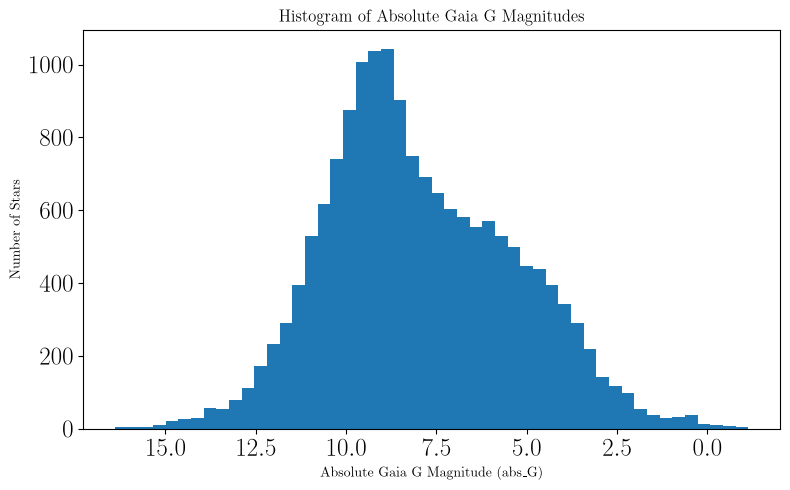

In [21]:
import matplotlib.pyplot as plt

# Keep only finite absolute magnitudes
abs_g = sample_sources_w_mass_radius["abs_G"]
abs_g = abs_g[np.isfinite(abs_g)]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(abs_g, bins=50)

plt.xlabel("Absolute Gaia G Magnitude (abs_G)")
plt.ylabel("Number of Stars")
plt.title("Histogram of Absolute Gaia G Magnitudes")

# Astronomers often invert magnitude axes
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

In [22]:
sample_sources_w_mass_radius.to_csv('./outputs/data/stars.csv', index=False)

In [23]:
sample_sources_w_mass_radius.columns

Index(['gaia_source_id', 'source_id_dr2', 'hip_id', 'ra', 'dec', 'ra_error',
       'dec_error', 'parallax', 'radial_velocity', 'pmra_hip',
       ...
       'predicted_class_msms', 'q_binary_msms', 'ra_msms',
       'radial_velocity_msms', 'radial_velocity_error_msms',
       'astrometric_chi2_al_dr3', 'parallax_error', 'abs_G', 'mass_interp',
       'radius_interp'],
      dtype='str', length=117)

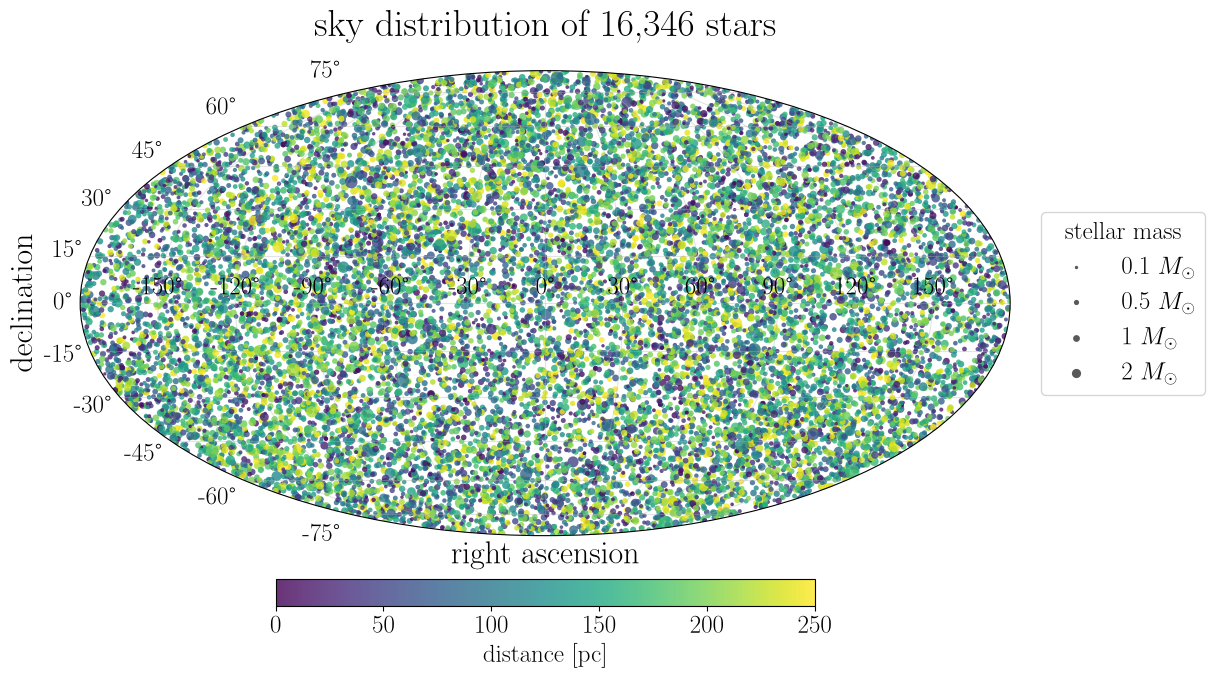

Saved outputs/figures/star_sky_distance.pdf


In [24]:
from pathlib import Path
from matplotlib.colors import Normalize

# Keep finite sky positions with positive parallaxes. Distance is in parsecs
# because parallax is stored in milliarcseconds.
sky = sample_sources_w_mass_radius.loc[
    np.isfinite(sample_sources_w_mass_radius["ra"])
    & np.isfinite(sample_sources_w_mass_radius["dec"])
    & np.isfinite(sample_sources_w_mass_radius["parallax"])
    & (sample_sources_w_mass_radius["parallax"] > 0)
    & np.isfinite(sample_sources_w_mass_radius["mass_interp"])
    & (sample_sources_w_mass_radius["mass_interp"] > 0)
    # restrict to the final parent sample: only stars with a reported sigma_AL
    # (the 16,346 that carry a Gaia noise model; drops the 33 without sig_AL)
    & sample_sources_w_mass_radius["sig_AL"].notna()
].copy()
sky["distance_pc"] = 1000.0 / sky["parallax"]

# Wrap RA to [-pi, pi] and reverse it so RA increases toward the left,
# following the usual astronomical sky-map convention.
ra_rad = np.deg2rad(sky["ra"].to_numpy())
ra_wrapped = np.remainder(ra_rad + np.pi, 2.0 * np.pi) - np.pi
ra_plot = -ra_wrapped
dec_plot = np.deg2rad(sky["dec"].to_numpy())
distance_pc = sky["distance_pc"].to_numpy()
mass_msun = sky["mass_interp"].to_numpy()

# Matplotlib's `s` is marker area, so this makes displayed area scale
# linearly with stellar mass while retaining a small visible minimum.
def mass_to_marker_area(mass):
    return 4.0 + 20.0 * np.asarray(mass)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection="mollweide")
points = ax.scatter(
    ra_plot,
    dec_plot,
    c=distance_pc,
    s=mass_to_marker_area(mass_msun),
    cmap="viridis",
    norm=Normalize(vmin=0.0, vmax=250.0),
    linewidths=0,
    alpha=0.8,
    rasterized=True,
)
ax.grid(True, alpha=0.35)
ax.set_xlabel("right ascension", fontsize=23)
ax.set_ylabel("declination", fontsize=23)
ax.set_title(
    rf"sky distribution of {len(sky):,} stars",
    pad=25, fontsize=27
)

legend_masses = [0.1, 0.5, 1.0, 2.0]
legend_handles = [
    ax.scatter(
        [], [], s=mass_to_marker_area(mass), color="0.35",
        linewidths=0, label=rf"{mass:g} $M_\odot$",
    )
    for mass in legend_masses
]
ax.legend(
    handles=legend_handles, title="stellar mass", loc="center left",
    bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=18, title_fontsize=18,
)
colorbar = fig.colorbar(points, ax=ax, orientation="horizontal", pad=0.08, fraction=0.05)
colorbar.set_label("distance [pc]", fontsize=18)

figure_path = Path("outputs/figures/star_sky_distance.pdf")
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(f"Saved {figure_path}")

/Users/daniel/opt/anaconda3/envs/epochalypse-arm64/lib/python3.11/site-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


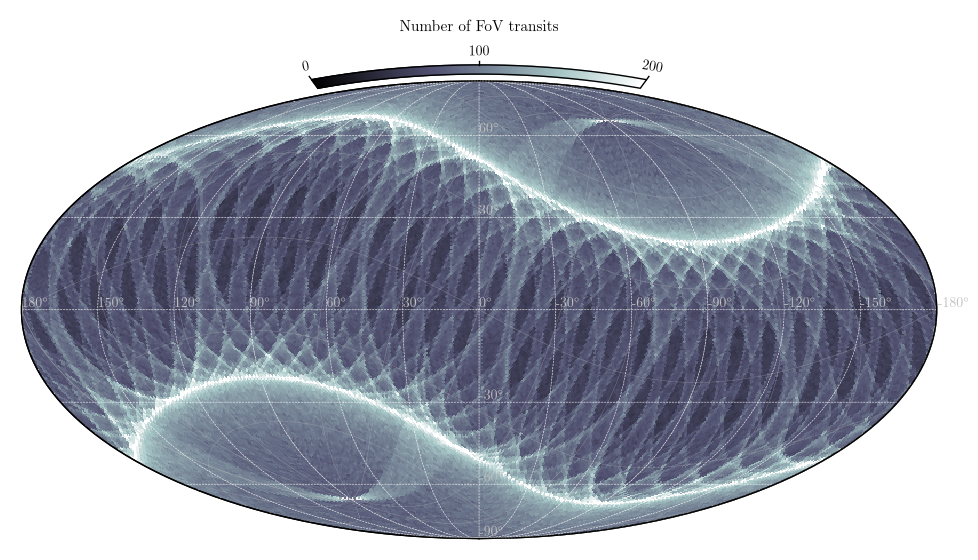

Saved outputs/figures/gost_scanlaw_equatorial.pdf


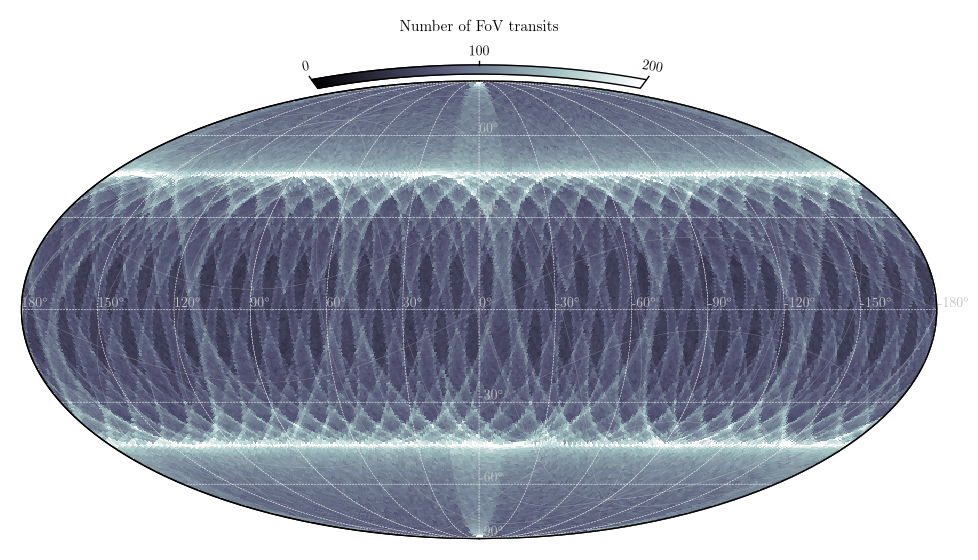

Saved outputs/figures/gost_scanlaw_ecliptic.pdf


In [25]:
# ==============================================================
# GOST DR4 scan law on-sky (healpy mollview, DR4 in both frames)
#
# Ported from plot_12sources_onsky.py (the 12 pre-release sources have been
# removed -- this renders the scan-law background only). Uses healpy's
# mollview so the NSIDE=64 transit-count map is drawn natively, with a curved
# colorbar hugging the top of the ellipse and dual graticules (dashed white =
# display frame, solid silver = the other frame).
# ==============================================================
import numpy as np
import healpy as hp
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from pathlib import Path


def add_curved_colorbar(ax, vmin, vmax, cmap, *, side="top", half_angle=20.0,
                        r_in=1.03, r_out=1.07, nseg=256,
                        ticks=None, label='', fontsize=10,
                        text_color='k', edge_color='k'):
    """Draw a colorbar as an annular arc hugging the TOP (north pole) or BOTTOM
    (south pole) edge of a healpy Mollweide ellipse.

    Geometry: healpy draws the Mollweide ellipse as (2 cos t, sin t) in axes
    data coordinates. The band lives between scaled ellipses r_in and r_out,
    spanning ellipse parameter t = center +/- half_angle degrees (center = +90
    for the top, -90 for the bottom). Values map linearly along the arc, vmin
    at the left end -> vmax at the right end.

    Call AFTER hp.mollview, on the healpy axes (plt.gca()).
    """
    cmap = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    top = (side == "top")
    center = 90.0 if top else -90.0

    # left end -> vmin, right end -> vmax (sign flips between top and bottom so
    # that both read left-to-right)
    t0 = np.radians(center + (half_angle if top else -half_angle))   # vmin end
    t1 = np.radians(center - (half_angle if top else -half_angle))   # vmax end
    t = np.linspace(t0, t1, nseg + 1)

    xi, yi = 2.0*r_in*np.cos(t),  r_in*np.sin(t)
    xo, yo = 2.0*r_out*np.cos(t), r_out*np.sin(t)

    verts = [[(xi[i], yi[i]), (xi[i+1], yi[i+1]),
              (xo[i+1], yo[i+1]), (xo[i], yo[i])] for i in range(nseg)]
    frac = (np.arange(nseg) + 0.5) / nseg
    cols = cmap(frac)
    # edgecolor = facecolor + small lw kills white hairline seams in PDF output
    ax.add_collection(PolyCollection(verts, facecolors=cols, edgecolors=cols,
                                     linewidths=1, zorder=5))
    # thin outline around the whole band
    ax.plot(np.r_[xi, xo[::-1], xi[:1]], np.r_[yi, yo[::-1], yi[:1]],
            color=edge_color, lw=1, zorder=6)

    # ticks + labels along the arc
    if ticks is None:
        ticks = np.linspace(vmin, vmax, 5)
    va = "bottom" if top else "top"       # text sits outside the ellipse
    for v in ticks:
        fv = (v - vmin) / (vmax - vmin)
        tt = t0 + fv*(t1 - t0)
        ct, st = np.cos(tt), np.sin(tt)
        ax.plot([2*r_out*ct, 2*(r_out+0.015)*ct],
                [r_out*st,   (r_out+0.015)*st],
                color=edge_color, lw=1, zorder=6)
        ang = np.degrees(np.arctan2(-ct, 2*st))   # local tangent, reads L->R
        if ang > 90:                              # keep labels upright
            ang -= 180
        elif ang < -90:
            ang += 180
        ax.text(2*(r_out+0.03)*ct, (r_out+0.03)*st, f'{v:g}',
                rotation=ang, rotation_mode='anchor',
                ha='center', va=va, fontsize=fontsize, color=text_color,
                zorder=6)

    if label:
        ylab = (r_out + 0.135) if top else -(r_out + 0.135)
        ax.text(0.0, ylab, label, ha='center', va=va,
                fontsize=fontsize + 1, color=text_color, zorder=6)

    # make room outside the ellipse for the band + labels
    y0, y1 = ax.get_ylim()
    if top:
        ax.set_ylim(min(y0, -1.05), max(y1, r_out + 0.24))
    else:
        ax.set_ylim(min(y0, -(r_out + 0.24)), max(y1, 1.05))
    x0, x1 = ax.get_xlim()
    ax.set_xlim(min(x0, -2.05), max(x1, 2.05))


# Load map (stored in equatorial 'C', RING ordering). badcolor/bgcolor white
# handles any unqueried (hp.UNSEEN) pixels from a mid-run snapshot.
GOST_MAP_PATH = "data/gost_fov_counts_dr4.fits"
m4 = hp.read_map(GOST_MAP_PATH)

# Render DR4 in both display frames. The MAP is always stored in equatorial
# ('C'); only the DISPLAY frame changes. Degree labels use $^\\circ$ so they
# render under usetex (set in the first cell).
for choice in ["equatorial", "ecliptic"]:
    if choice == "equatorial":
        mollview_coord = "C"            # no rotation: display = storage frame
        display_grat   = "Equatorial"   # grid matching display -> straight lines
        foreign_grat   = "Ecliptic"     # the other frame -> curved lines
        label_coord    = "C"            # label positions given in RA/Dec
    else:
        mollview_coord = ["C", "E"]     # rotate map from equatorial to ecliptic
        display_grat   = "Ecliptic"
        foreign_grat   = "Equatorial"
        label_coord    = "E"

    fig = plt.figure(figsize=(10, 6))

    # cbar=False: we add our own curved colorbar. badcolor='white': mid-run
    # UNSEEN pixels render white instead of grey.
    hp.visufunc.mollview(m4, fig=fig.number, coord=mollview_coord, title="",
                         cbar=False, cmap="bone", notext=True, min=0, max=200,
                         badcolor="white", bgcolor="white", flip="astro")

    # display-frame grid (straight) + foreign-frame grid (curved)
    hp.visufunc.graticule(coord=foreign_grat, c="silver", linestyle="solid",
                          lw=0.3, dpar=30, dmer=30, alpha=0.5)
    hp.visufunc.graticule(coord=display_grat, c="w", linestyle="dashed",
                          lw=0.4, dpar=30, dmer=30)

    # Parallel (latitude) labels along the central meridian of the DISPLAY frame
    for lat in [-90, -60, -30, 30, 60]:
        hp.visufunc.projtext(0, lat, rf"{lat}$^\circ$", lonlat=True,
                             coord=label_coord, fontweight="bold", fontsize=10,
                             color="silver", ha="left", va="bottom")

    # Meridian (longitude) labels along the display-frame equator, signed +/-180
    for lon_signed in [-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150]:
        lon_plot = lon_signed % 360
        hp.visufunc.projtext(lon_plot, 0, rf"{lon_signed}$^\circ$", lonlat=True,
                             coord=label_coord, fontweight="bold", fontsize=10,
                             color="silver", ha="left", va="bottom")

    ax = plt.gca()
    ax.text(-2.0, 0.0, r"180$^\circ$",  fontweight="bold", ha="left",
            va="bottom", fontsize=10, color="silver")
    ax.text(2.005, 0.0, r"-180$^\circ$", fontweight="bold", ha="left",
            va="bottom", fontsize=10, color="silver")

    # curved colorbar hugging the north edge of the ellipse
    im = ax.get_images()[0]
    vmin, vmax = im.get_clim()          # inherits min=0, max=200
    add_curved_colorbar(ax, vmin, vmax, "bone", side="top",
                        ticks=[0, 100, 200],
                        label="Number of FoV transits")

    scanlaw_path = Path(f"outputs/figures/gost_scanlaw_{choice}.pdf")
    scanlaw_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(scanlaw_path, bbox_inches="tight")
    plt.show()
    print(f"Saved {scanlaw_path}")


/Users/daniel/opt/anaconda3/envs/epochalypse-arm64/lib/python3.11/site-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


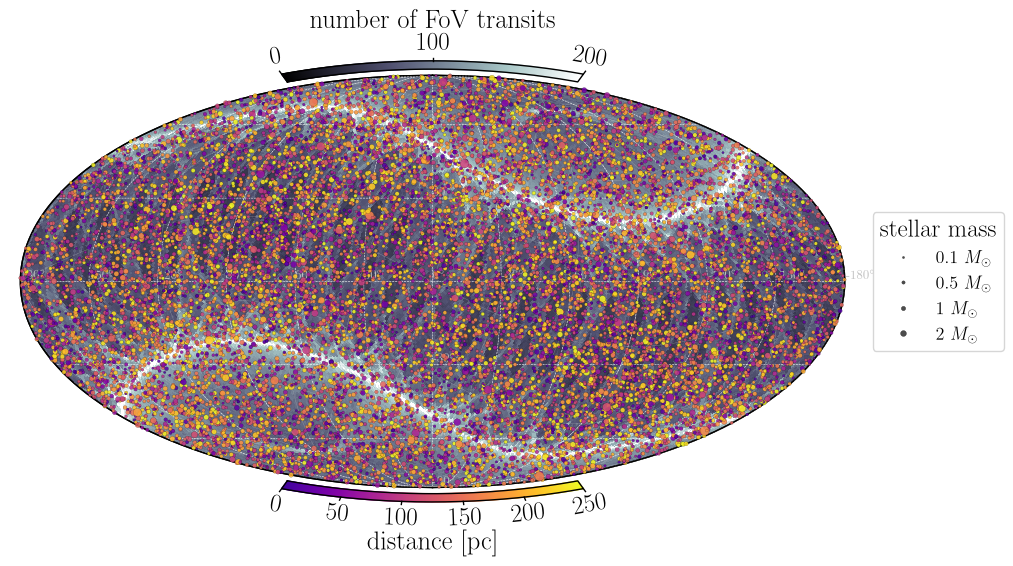

Saved outputs/figures/star_sky_scanlaw_equatorial.pdf


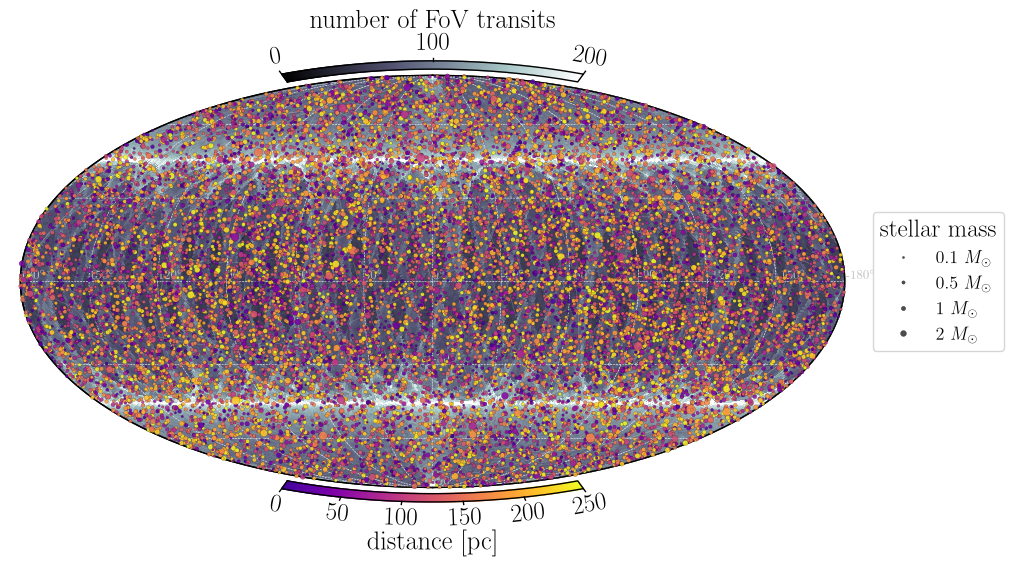

Saved outputs/figures/star_sky_scanlaw_ecliptic.pdf


In [26]:
# ==============================================================
# Stars over the healpy GOST DR4 scan law (DR4, both frames)
#
# Single mollview per frame with the stellar sample on top via hp.projscatter:
# colour = distance [pc], marker area ~ stellar mass, clipped 'plasma' map +
# a very light outline so the dots read on the scan-law background. Two matching curved
# colorbars hug the ellipse: FoV transits at the top, distance at the bottom.
# Reuses add_curved_colorbar / m4 / GOST_MAP_PATH from the cell above.
# ==============================================================
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.lines import Line2D

# Keep finite sky positions with positive parallaxes / masses. Distance is in
# parsecs because parallax is stored in milliarcseconds.
sky = sample_sources_w_mass_radius.loc[
    np.isfinite(sample_sources_w_mass_radius["ra"])
    & np.isfinite(sample_sources_w_mass_radius["dec"])
    & np.isfinite(sample_sources_w_mass_radius["parallax"])
    & (sample_sources_w_mass_radius["parallax"] > 0)
    & np.isfinite(sample_sources_w_mass_radius["mass_interp"])
    & (sample_sources_w_mass_radius["mass_interp"] > 0)
    # restrict to the final parent sample: only stars with a reported sigma_AL
    # (the 16,346 that carry a Gaia noise model; drops the 33 without sig_AL)
    & sample_sources_w_mass_radius["sig_AL"].notna()
].copy()
sky["distance_pc"] = 1000.0 / sky["parallax"]

star_ra   = sky["ra"].to_numpy()
star_dec  = sky["dec"].to_numpy()
star_dist = sky["distance_pc"].to_numpy()
star_mass = sky["mass_interp"].to_numpy()

# Matplotlib's `s` is marker area. Keep the mass scaling deliberately compact
# so the all-sky distribution and scan-law structure remain legible.
def mass_to_marker_area(mass):
    return 1.5 + 8.0 * np.asarray(mass)

# Clip plasma's darkest 10% so nearby stars remain visible on dark map pixels.
plasma = plt.get_cmap("plasma")
star_cmap = LinearSegmentedColormap.from_list(
    "plasma_clipped", plasma(np.linspace(0.1, 1.0, 256))
)
star_vmax = 250.0
star_norm = Normalize(vmin=0.0, vmax=star_vmax)


def decorate_skymap(ax, display_grat, foreign_grat, label_coord):
    """Graticules, meridian/parallel labels, and the curved FoV colorbar (top)
    for a healpy mollview panel (call with the panel's axes as current)."""
    # display-frame grid (straight) + foreign-frame grid (curved)
    hp.visufunc.graticule(coord=foreign_grat, c="silver", linestyle="solid",
                          lw=0.3, dpar=30, dmer=30, alpha=0.5)
    hp.visufunc.graticule(coord=display_grat, c="w", linestyle="dashed",
                          lw=0.4, dpar=30, dmer=30)
    for lat in [-90, -60, -30, 30, 60]:
        hp.visufunc.projtext(0, lat, rf"{lat}$^\circ$", lonlat=True,
                             coord=label_coord, fontweight="bold", fontsize=9,
                             color="silver", ha="left", va="bottom")
    for lon_signed in [-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150]:
        hp.visufunc.projtext(lon_signed % 360, 0, rf"{lon_signed}$^\circ$",
                             lonlat=True, coord=label_coord, fontweight="bold",
                             fontsize=9, color="silver", ha="left", va="bottom")
    ax.text(-2.0, 0.0, r"180$^\circ$", fontweight="bold", ha="left",
            va="bottom", fontsize=9, color="silver")
    ax.text(2.005, 0.0, r"-180$^\circ$", fontweight="bold", ha="left",
            va="bottom", fontsize=9, color="silver")
    im = ax.get_images()[0]
    vmin, vmax = im.get_clim()
    add_curved_colorbar(ax, vmin, vmax, "bone", side="top", ticks=[0, 100, 200],
                        label="number of FoV transits", fontsize=18)


for choice in ["equatorial", "ecliptic"]:
    if choice == "equatorial":
        mollview_coord = "C"
        display_grat   = "Equatorial"
        foreign_grat   = "Ecliptic"
        label_coord    = "C"
    else:
        mollview_coord = ["C", "E"]
        display_grat   = "Ecliptic"
        foreign_grat   = "Equatorial"
        label_coord    = "E"

    fig = plt.figure(figsize=(10, 6))

    hp.visufunc.mollview(m4, fig=fig.number, coord=mollview_coord, title="",
                         cbar=False, cmap="bone", notext=True, min=0, max=200,
                         badcolor="white", bgcolor="white", flip="astro")
    ax = plt.gca()

    # stars: positions in RA/Dec (coord='C'), healpy rotates them into the
    # display frame; colour = distance, marker area ~ stellar mass, thin dark edge.
    hp.visufunc.projscatter(star_ra, star_dec, lonlat=True, coord="C",
                            c=star_dist, s=mass_to_marker_area(star_mass),
                            cmap=star_cmap, norm=star_norm,
                            edgecolors="k", linewidths=0.12, alpha=0.88, zorder=10)

    decorate_skymap(ax, display_grat, foreign_grat, label_coord)

    # distance colorbar: matching curved arc hugging the SOUTH edge
    add_curved_colorbar(ax, 0, star_vmax, star_cmap, side="bottom",
                        ticks=[0, 50, 100, 150, 200, 250], label="distance [pc]", fontsize=18)

    # stellar-mass size legend (marker size in points ~ sqrt of area in points^2)
    legend_handles = [
        Line2D([], [], marker="o", linestyle="none", markerfacecolor="0.3",
               markeredgecolor="k", markeredgewidth=0.2,
               markersize=np.sqrt(mass_to_marker_area(mm)),
               label=rf"{mm:g} $M_\odot$")
        for mm in [0.1, 0.5, 1.0, 2.0]
    ]
    ax.legend(handles=legend_handles, title="stellar mass", loc="center left",
              bbox_to_anchor=(1.01, 0.5), frameon=True, fontsize=13,
              title_fontsize=18)

    both_path = Path(f"outputs/figures/star_sky_scanlaw_{choice}.pdf")
    fig.savefig(both_path, bbox_inches="tight")
    plt.show()
    print(f"Saved {both_path}")
